In [75]:
import pandas as pd 
import numpy as np
import openpyxl
import seaborn as sns 
import matplotlib.pyplot as plt
sns.set(style="whitegrid")


In [44]:
df = pd.read_excel("student_habits_performance.xlsx")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [45]:
df['study_hours_per_day'].isnull().sum()

np.int64(0)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [47]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [48]:
df['parental_education_level'].isnull().sum()

np.int64(91)

In [49]:
#most occuring value in parental educatipnal level
mode_value = df['parental_education_level'].mode()[0]

df['parental_education_level'].fillna(mode_value, inplace=True)

In [50]:
df.head(5)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [51]:
df['social_media_hours'] = df['social_media_hours'] + df['netflix_hours']
df.drop(columns=['netflix_hours'], inplace=True)
df['social_media_hours']

0      2.3
1      5.1
2      4.4
3      4.9
4      4.9
      ... 
995    2.1
996    3.4
997    3.9
998    5.2
999    4.8
Name: social_media_hours, Length: 1000, dtype: float64

In [52]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [53]:
#Remove extra space or incosistencies
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [54]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

### Attribute wise Distributions

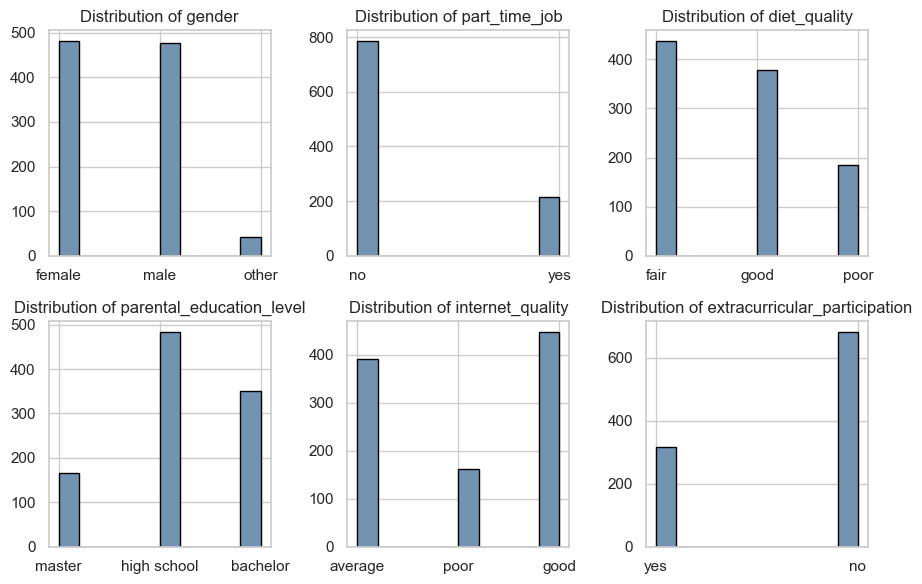

In [59]:
cat_col = df.select_dtypes(include='object').columns
cat_col = [col for col in cat_col]
cat_col.remove('student_id')
cat_col
plt.figure(figsize=(9,6))
for i in range(6):
    plt.subplot(2, 3, i+1)  
    
    plt.hist(df[cat_col[i]], color='#7393B3', edgecolor='black')
    plt.title(f'Distribution of {cat_col[i]}')
    
plt.tight_layout()
plt.show()  


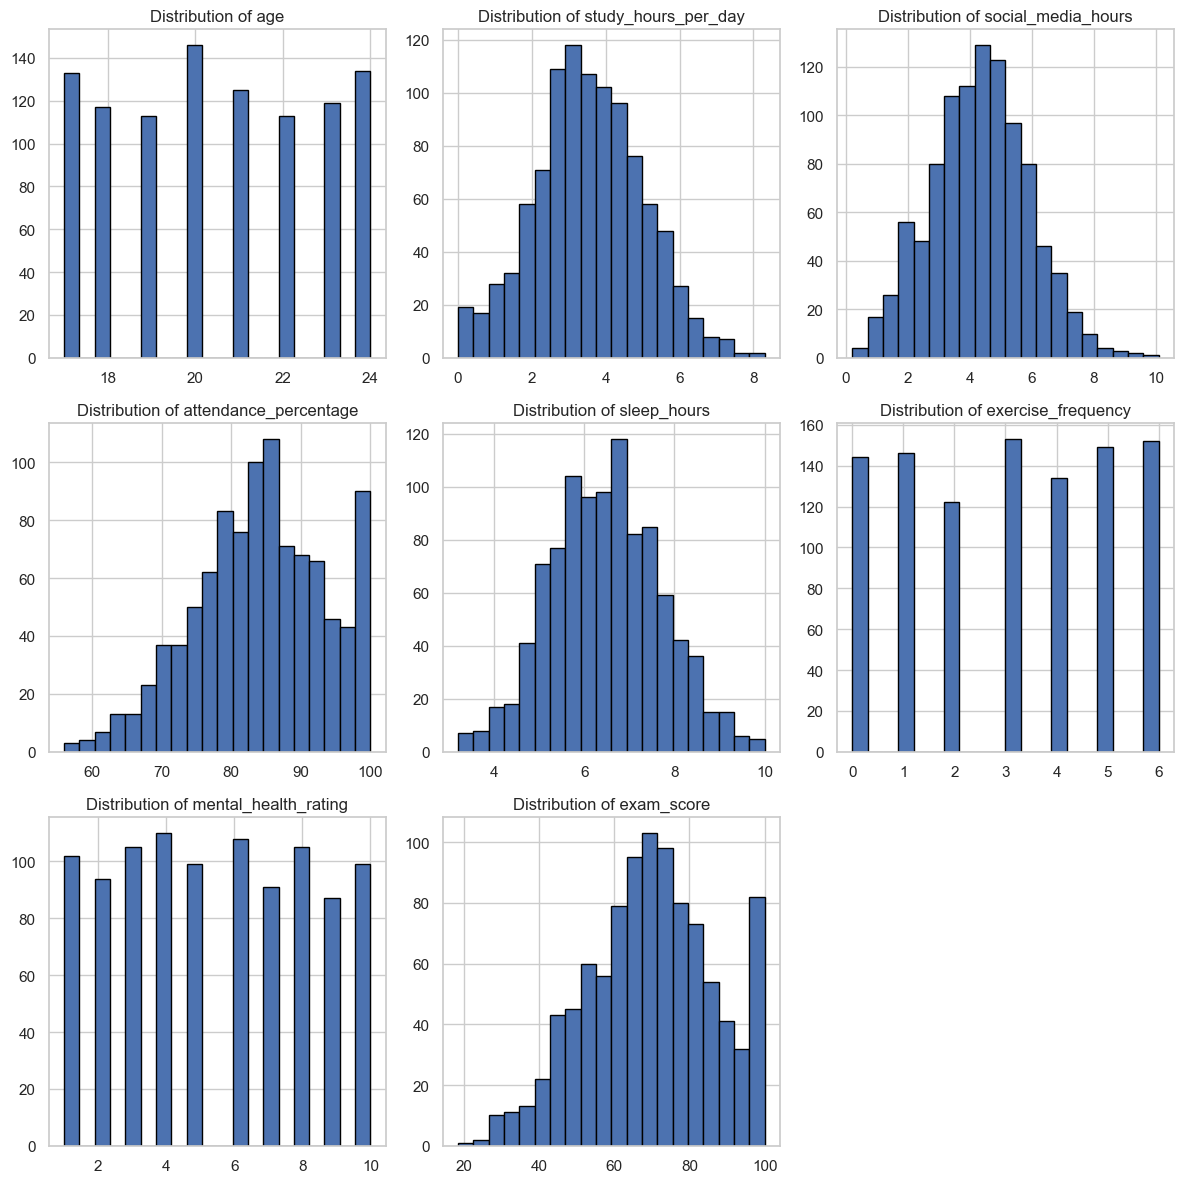

In [63]:
num_col = df.select_dtypes(exclude='object').columns
num_col = [col for col in num_col]
num_col
plt.figure(figsize=(12,12))
for i in range(0,8):
    plt.subplot(3, 3, i+1)  # subplot index starts at 1
    plt.hist(df[num_col[i]],bins=20, edgecolor='black')
    plt.title(f'Distribution of {num_col[i]}')
    
plt.tight_layout()
plt.show()

In [66]:
df2 = df.drop('student_id', axis=1)
df2.head()

,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,female,0.0,2.3,no,85.0,8.0,fair,6,master,average,8,yes,56.2
1,20,female,6.9,5.1,no,97.3,4.6,good,6,high school,average,8,no,100.0
2,21,male,1.4,4.4,no,94.8,8.0,poor,1,high school,poor,1,no,34.3
3,23,female,1.0,4.9,no,71.0,9.2,poor,4,master,good,1,yes,26.8
4,19,female,5.0,4.9,no,90.9,4.9,fair,3,master,good,1,no,66.4


In [67]:
df[cat_col].describe()

,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,1000,1000
unique,3,2,3,3,3,2
top,female,no,fair,high school,good,no
freq,481,785,437,483,447,682


### Label Encoding and One Hot Encoding

In [64]:
for col in cat_col:
    print(col)

gender
part_time_job
diet_quality
parental_education_level
internet_quality
extracurricular_participation


In [70]:
diet_quality = {'poor': 0, 'fair': 1, 'good': 2}
parental_education_level = {'high school': 0, 'bachelor': 1, 'master': 2}
internet_quality = {'poor': 0, 'average': 1, 'good': 2}

In [71]:
df2['dq_e'] = df2['diet_quality'].map(diet_quality)
df2['pel_e'] = df2['parental_education_level'].map(parental_education_level)
df2['iq_e'] = df2['internet_quality'].map(internet_quality)

In [73]:
df2.head()

,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,dq_e,pel_e,iq_e
0,23,female,0.0,2.3,no,85.0,8.0,fair,6,master,average,8,yes,56.2,1,2,1
1,20,female,6.9,5.1,no,97.3,4.6,good,6,high school,average,8,no,100.0,2,0,1
2,21,male,1.4,4.4,no,94.8,8.0,poor,1,high school,poor,1,no,34.3,0,0,0
3,23,female,1.0,4.9,no,71.0,9.2,poor,4,master,good,1,yes,26.8,0,2,2
4,19,female,5.0,4.9,no,90.9,4.9,fair,3,master,good,1,no,66.4,1,2,2


#### CORRELATION ANALYSIS

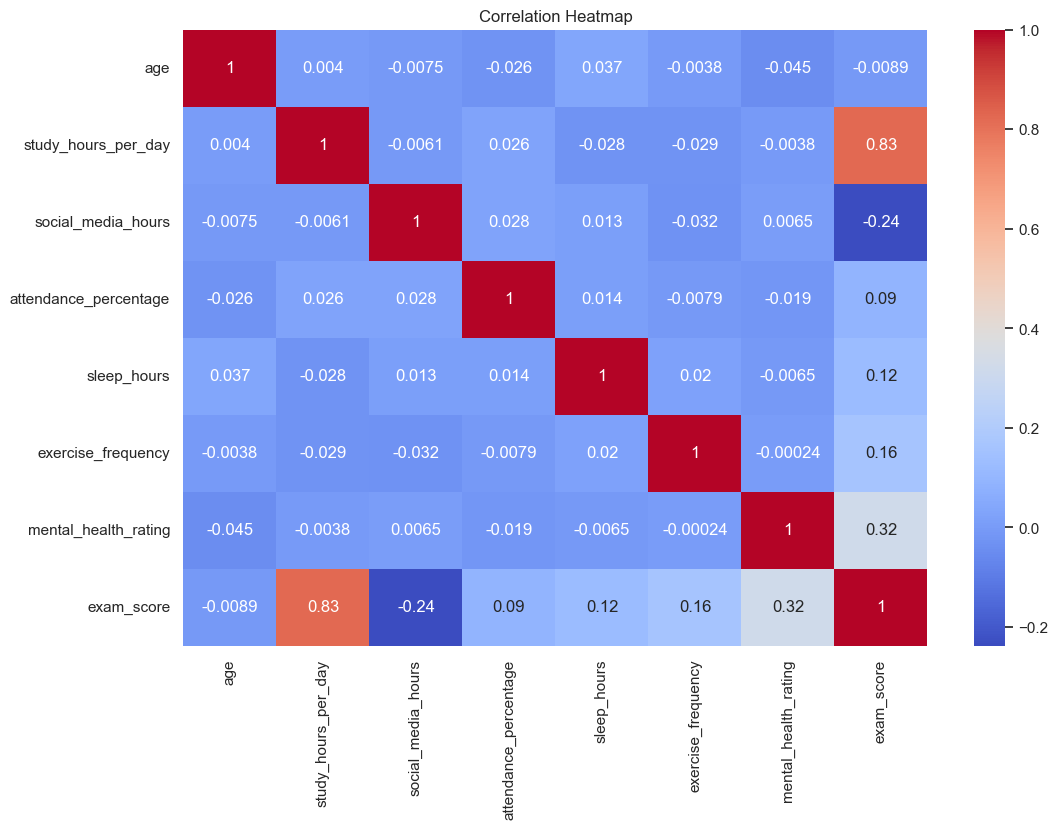

In [74]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

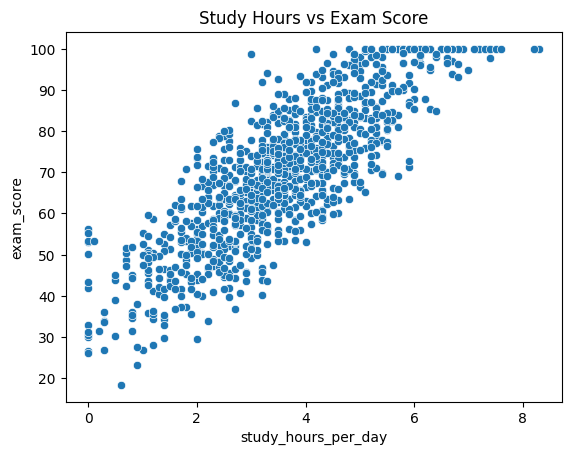

In [16]:
#study hours vs score
sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df)
plt.title("Study Hours vs Exam Score")
plt.show()

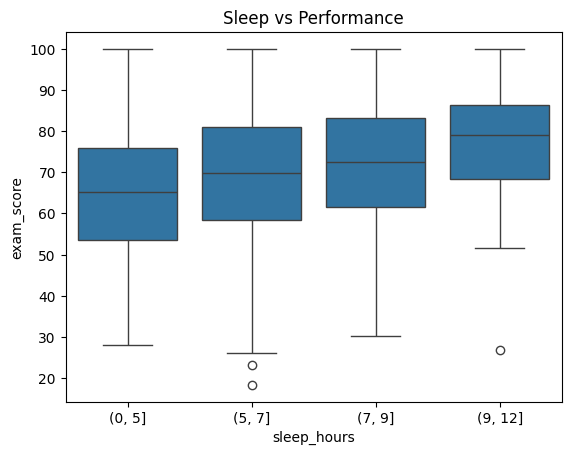

In [17]:
#sleep hours vs score
sns.boxplot(x=pd.cut(df['sleep_hours'], bins=[0,5,7,9,12]),
            y='exam_score',
            data=df)
plt.title("Sleep vs Performance")
plt.show()

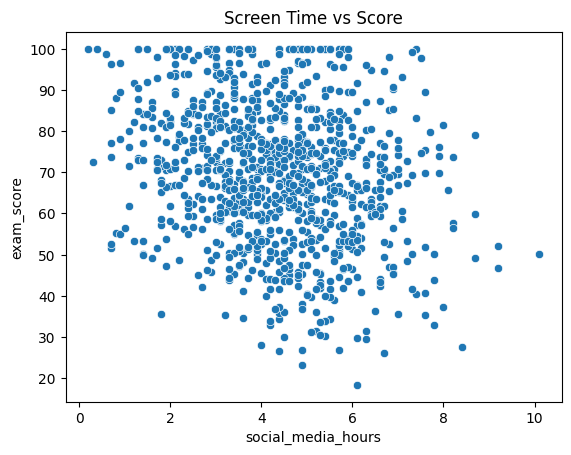

In [18]:
#social media hours vs score
sns.scatterplot(x='social_media_hours', y='exam_score', data=df)
plt.title("Screen Time vs Score")
plt.show()

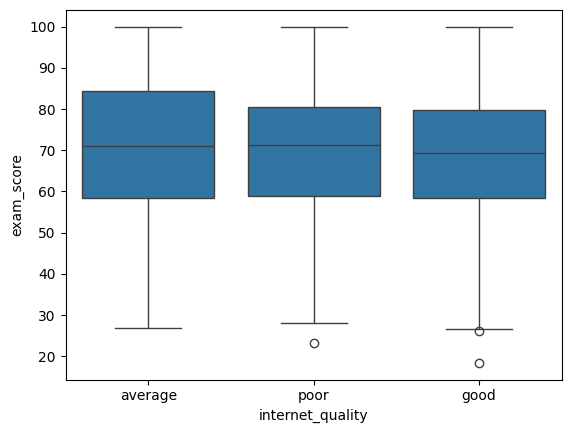

In [19]:
#internet quality vs exam_score
sns.boxplot(x='internet_quality', y='exam_score', data=df)
plt.show()

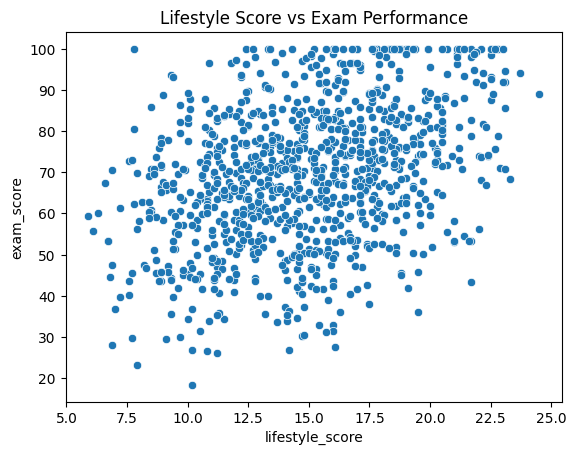

In [21]:
df['lifestyle_score'] = (
    df['sleep_hours'] +
    df['exercise_frequency'] +
    df['mental_health_rating']
)
sns.scatterplot(x='lifestyle_score', y='exam_score', data=df)
plt.title("Lifestyle Score vs Exam Performance")
plt.show()

### Gender Wise Analysis

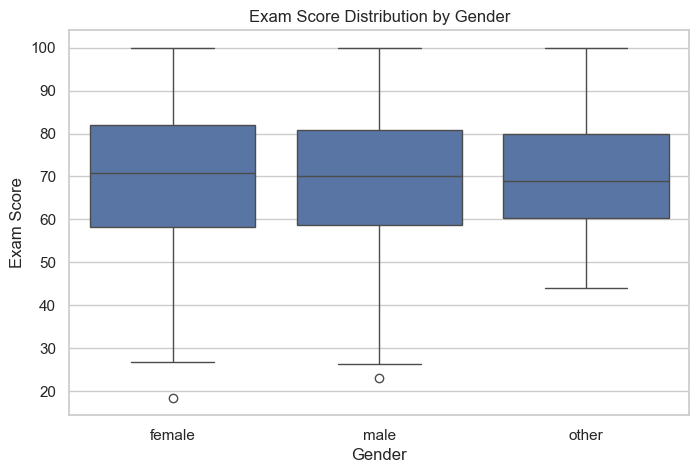

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='exam_score', data=df)

plt.title("Exam Score Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Exam Score")

plt.show()

#### Study and Sleep hours vs Exam Score

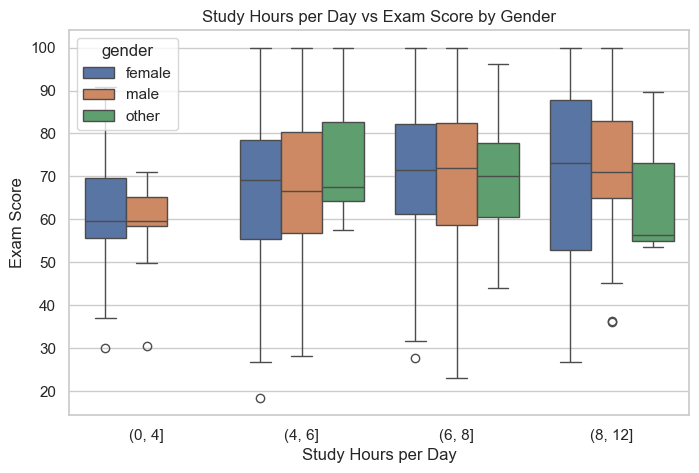

In [38]:
plt.figure(figsize=(8,5))

study_bins = pd.cut(df['sleep_hours'], bins=[0,4,6,8,12])

sns.boxplot(
    x=study_bins,
    y='exam_score',
    hue='gender',
    data=df
)

plt.title("Study Hours per Day vs Exam Score by Gender")
plt.xlabel("Study Hours per Day")
plt.ylabel("Exam Score")

plt.show()

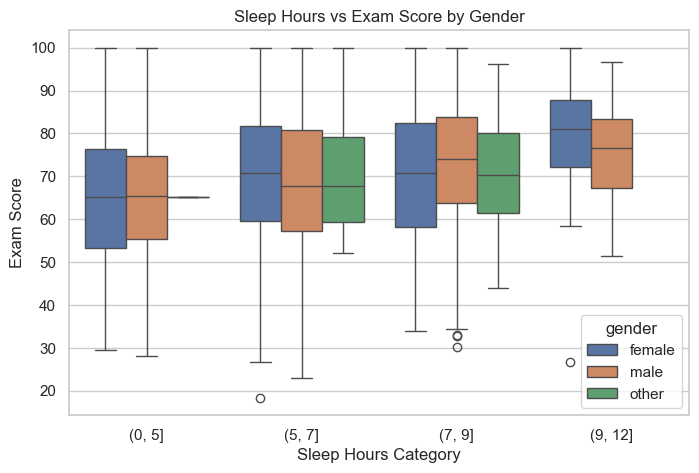

In [28]:
plt.figure(figsize=(8,5))

sleep_bins = pd.cut(df['sleep_hours'], bins=[0,5,7,9,12])

sns.boxplot(
    x=sleep_bins,
    y='exam_score',
    hue='gender',
    data=df
)

plt.title("Sleep Hours vs Exam Score by Gender")
plt.xlabel("Sleep Hours Category")
plt.ylabel("Exam Score")

plt.show()

#### Attendance vs Exam score


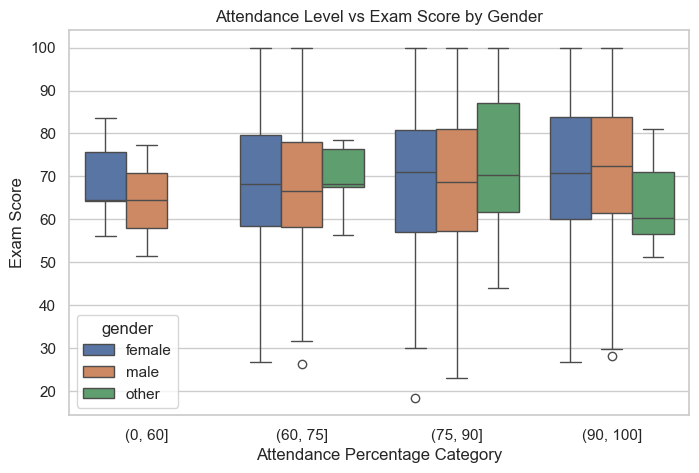

In [30]:
plt.figure(figsize=(8,5))

attendance_bins = pd.cut(df['attendance_percentage'], bins=[0,60,75,90,100])

sns.boxplot(
    x=attendance_bins,
    y='exam_score',
    hue='gender',
    data=df
)

plt.title("Attendance Level vs Exam Score by Gender")
plt.xlabel("Attendance Percentage Category")
plt.ylabel("Exam Score")

plt.show()

#### Overall Lifestyle Comparison

<Figure size 1000x600 with 0 Axes>

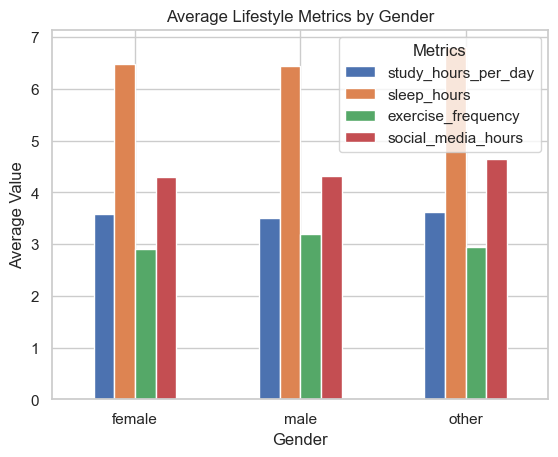

In [32]:
plt.figure(figsize=(10,6))

df.groupby('gender')[[
    'study_hours_per_day',
    'sleep_hours',
    'exercise_frequency',
    'social_media_hours'
]].mean().plot(kind='bar')

plt.title("Average Lifestyle Metrics by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.legend(title="Metrics")
plt.show()

In [23]:
df.to_excel("student_habit_performance_cleaned.xlsx")

In [40]:
df.head(4)

,student_id,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,lifestyle_score,productivity_score
0,s1000,23,female,0.0,2.3,no,85.0,8.0,fair,6,master,average,8,yes,56.2,22.0,6.20
1,s1001,20,female,6.9,5.1,no,97.3,4.6,good,6,high school,average,8,no,100.0,18.6,11.53
2,s1002,21,male,1.4,4.4,no,94.8,8.0,poor,1,high school,poor,1,no,34.3,10.0,6.48
3,s1003,23,female,1.0,4.9,no,71.0,9.2,poor,4,master,good,1,yes,26.8,14.2,3.20
